<a href="https://colab.research.google.com/github/Foysal061/Api-testing/blob/master/MedianEdArrival.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MEDIAN ED ARRIVAL FORECAST

[1/6] Loading ED data...
   Loaded 35674 valid records
   Date range: 2023-10-01 13:46:00 to 2024-10-25 12:35:00

[2/6] Building hourly arrival counts...
   Total hourly slots: 9360
   Range: 2023-10-01 13:00:00 to 2024-10-25 12:00:00

[3/6] Splitting into train (4 months) and test (next 7 days)...

   TRAIN period (4 months):
     Range: 2024-06-18 00:00:00 to 2024-10-17 23:00:00
     Hours: 2928
     Days:  122

   TEST period (7 days):
     Range: 2024-10-18 00:00:00 to 2024-10-25 12:00:00
     Hours: 181
     Days:  8

[4/6] Computing median from training data...
   Median lookup: 168 entries (7 days x 24 hours)

   Day          Hour   Median    Mean   Min   Max  Weeks
   -------------------------------------------------------
   Monday          0      2.0    2.24     0     5     17
   Monday          1      2.0    2.06     0     5     17
   Monday          2      1.0    1.29     0     3     17
   Monday          3      2.0    1.65     0     3     17
   

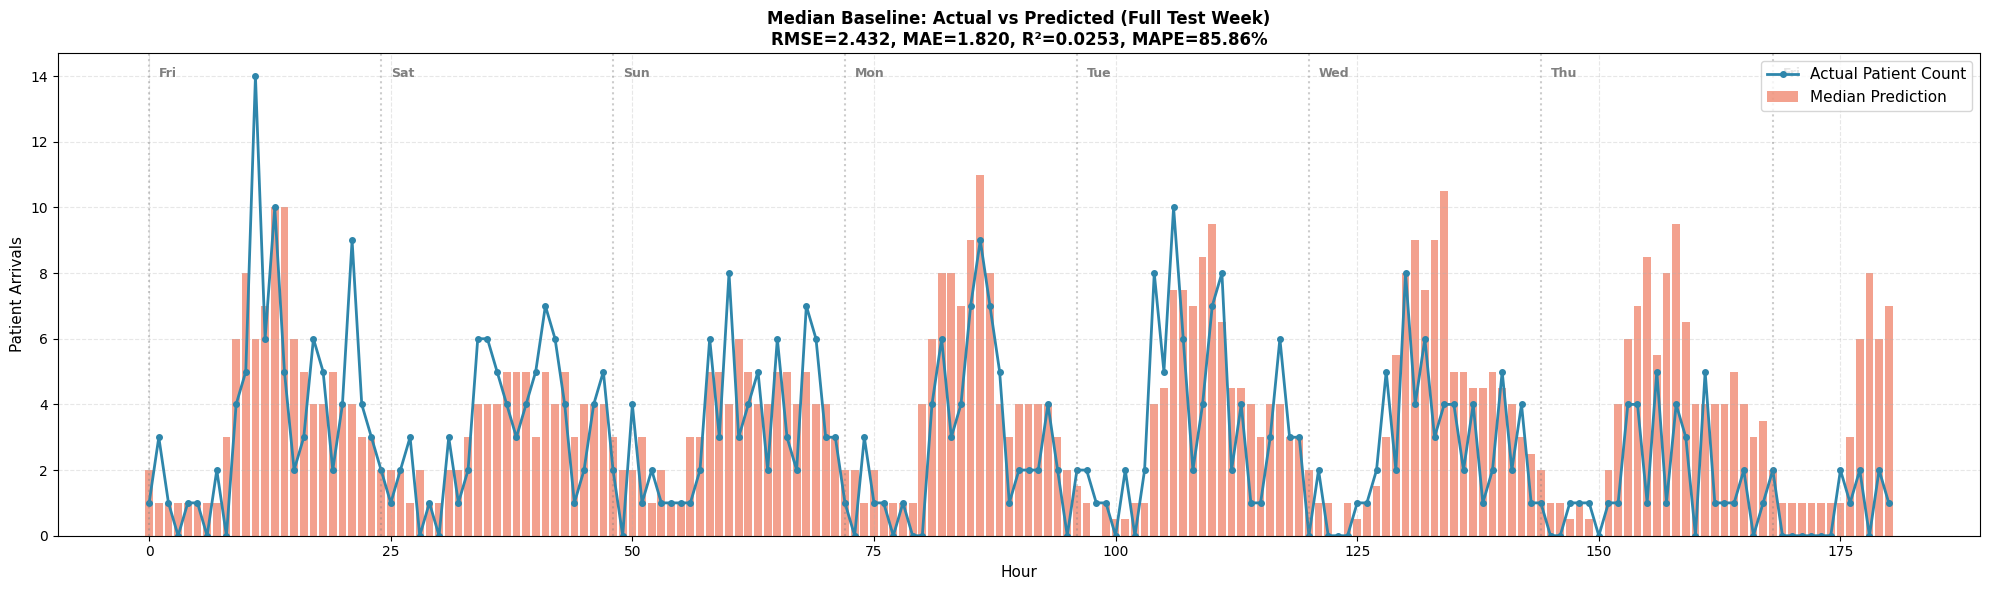

   Saved: median_last_24h_actual_vs_predicted.png


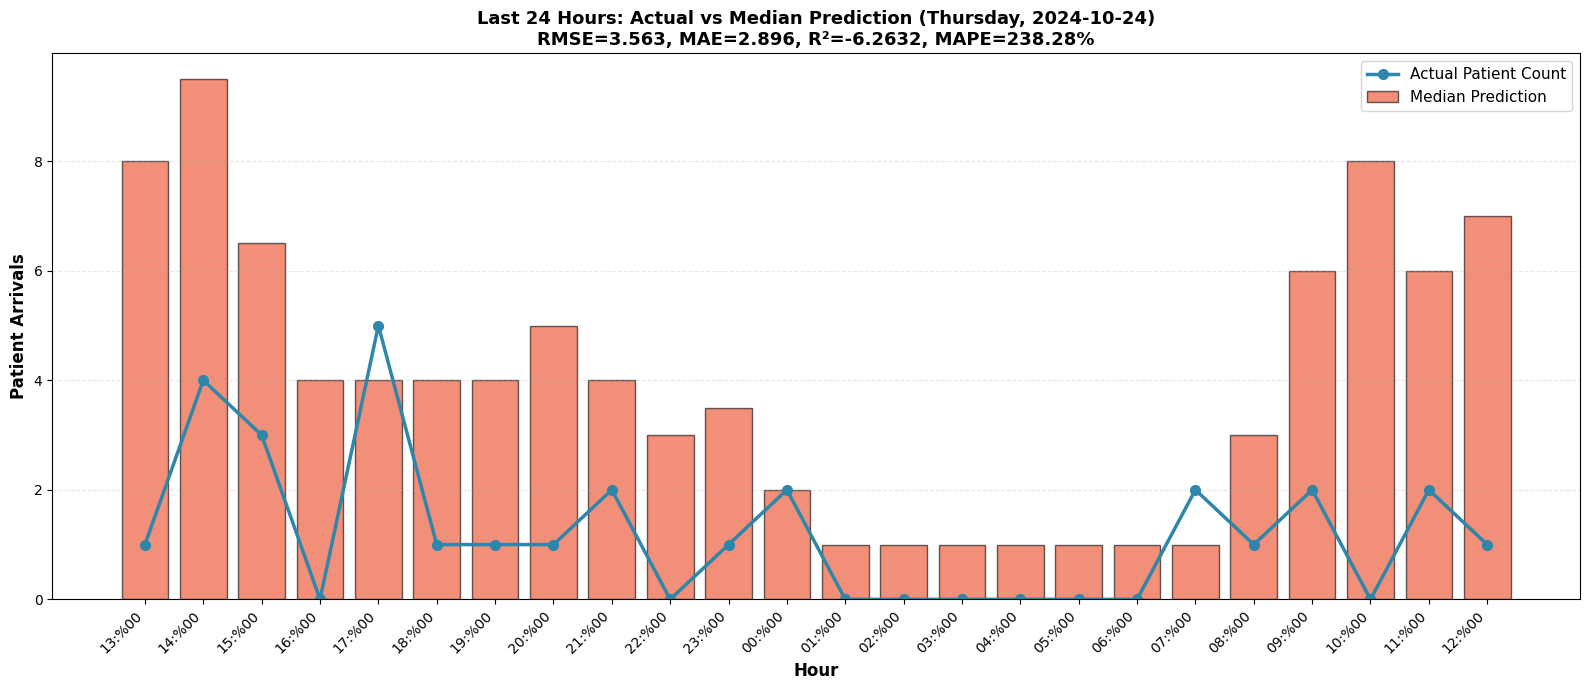

   Saved: median_arrivals_heatmap.png


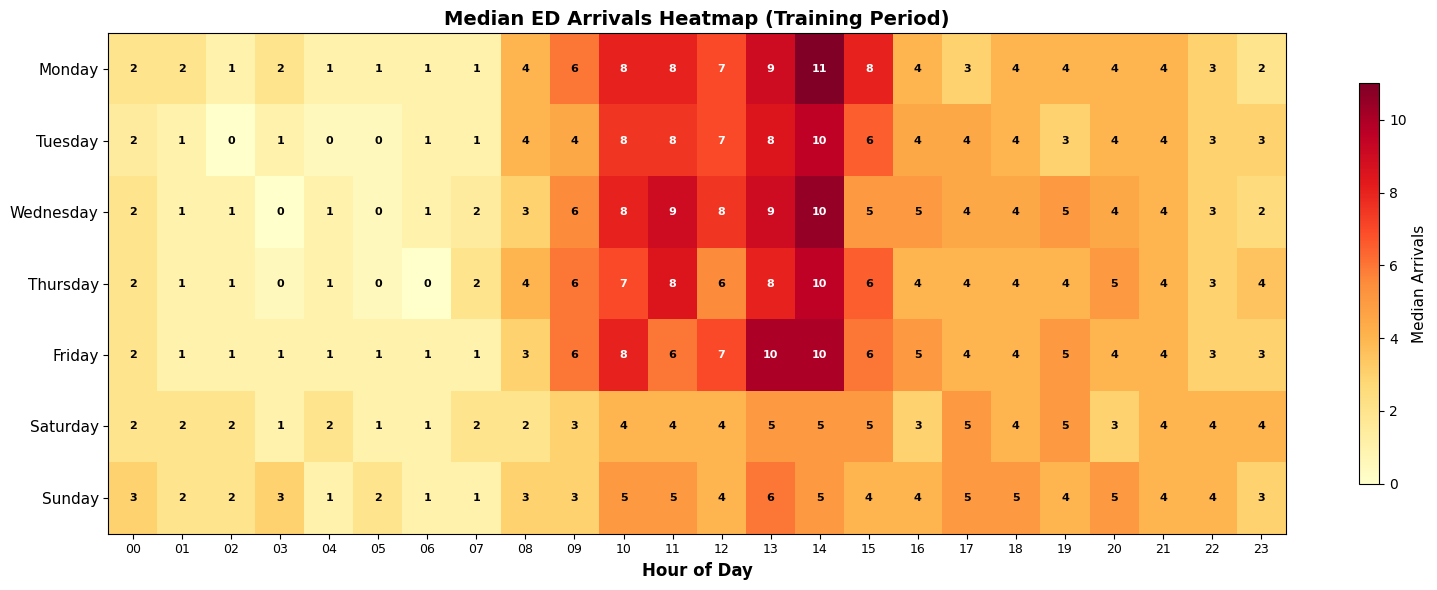


SUMMARY

   Train: 2024-06-18 to 2024-10-17 (2928 hours)
   Test:  2024-10-18 to 2024-10-25 (181 hours)

   Overall:  RMSE=2.432, MAE=1.820, R²=0.0253, MAPE=85.86%
   Last 24h: RMSE=3.563, MAE=2.896, R²=-6.2632, MAPE=238.28%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURATION
# =============================================================================

ED_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/VestfoldTriageReport.csv"
MONTHS_BACK = 4

# =============================================================================
# STEP 1: LOAD AND PARSE ED DATA
# =============================================================================

print("=" * 60)
print("MEDIAN ED ARRIVAL FORECAST")
print("=" * 60)

print("\n[1/6] Loading ED data...")
df = pd.read_csv(ED_DATA_PATH, sep=';')
df.columns = ['arrival', 'departure', 'first_doctor_response', 'first_triage']

df['arrival'] = pd.to_datetime(df['arrival'], format='%d.%m.%Y %H:%M', errors='coerce')
df = df.dropna(subset=['arrival']).sort_values('arrival')
print(f"   Loaded {len(df)} valid records")
print(f"   Date range: {df['arrival'].min()} to {df['arrival'].max()}")


# =============================================================================
# STEP 2: BUILD COMPLETE HOURLY COUNTS
# =============================================================================

print(f"\n[2/6] Building hourly arrival counts...")

df['arrival_hour'] = df['arrival'].dt.floor('H')
hourly_raw = df.groupby('arrival_hour').size().reset_index(name='arrival_count')

# Fill missing hours with 0
full_range = pd.date_range(
    start=hourly_raw['arrival_hour'].min(),
    end=hourly_raw['arrival_hour'].max(),
    freq='H'
)
hourly_all = pd.DataFrame({'arrival_hour': full_range})
hourly_all = hourly_all.merge(hourly_raw, on='arrival_hour', how='left')
hourly_all['arrival_count'] = hourly_all['arrival_count'].fillna(0).astype(int)
hourly_all['date'] = hourly_all['arrival_hour'].dt.date
hourly_all['hour'] = hourly_all['arrival_hour'].dt.hour
hourly_all['dayofweek'] = hourly_all['arrival_hour'].dt.dayofweek
hourly_all['day_name'] = hourly_all['arrival_hour'].dt.day_name()

print(f"   Total hourly slots: {len(hourly_all)}")
print(f"   Range: {hourly_all['arrival_hour'].min()} to {hourly_all['arrival_hour'].max()}")


# =============================================================================
# STEP 3: SPLIT — LAST 4 MONTHS = TRAIN, NEXT 7 DAYS = TEST
# =============================================================================

print(f"\n[3/6] Splitting into train (4 months) and test (next 7 days)...")

latest = hourly_all['arrival_hour'].max()

# Test = last 7 days
test_start = (latest - pd.Timedelta(days=7)).floor('D')
test_end = latest

# Train = 4 months before test starts
train_start = test_start - pd.DateOffset(months=MONTHS_BACK)

train_data = hourly_all[
    (hourly_all['arrival_hour'] >= train_start) &
    (hourly_all['arrival_hour'] < test_start)
].copy()

test_data = hourly_all[
    (hourly_all['arrival_hour'] >= test_start) &
    (hourly_all['arrival_hour'] <= test_end)
].copy()

print(f"\n   TRAIN period ({MONTHS_BACK} months):")
print(f"     Range: {train_data['arrival_hour'].min()} to {train_data['arrival_hour'].max()}")
print(f"     Hours: {len(train_data)}")
print(f"     Days:  {train_data['date'].nunique()}")

print(f"\n   TEST period (7 days):")
print(f"     Range: {test_data['arrival_hour'].min()} to {test_data['arrival_hour'].max()}")
print(f"     Hours: {len(test_data)}")
print(f"     Days:  {test_data['date'].nunique()}")


# =============================================================================
# STEP 4: COMPUTE MEDIAN FROM TRAIN DATA ONLY
# =============================================================================

print(f"\n[4/6] Computing median from training data...")

day_names_ordered = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

median_df = train_data.groupby(['dayofweek', 'day_name', 'hour']).agg(
    median_arrivals=('arrival_count', 'median'),
    mean_arrivals=('arrival_count', 'mean'),
    count_weeks=('arrival_count', 'count'),
    min_arrivals=('arrival_count', 'min'),
    max_arrivals=('arrival_count', 'max'),
    q25=('arrival_count', lambda x: np.percentile(x, 25)),
    q75=('arrival_count', lambda x: np.percentile(x, 75))
).reset_index()

median_df = median_df.sort_values(['dayofweek', 'hour'])

# Build lookup
median_lookup = {}
for _, row in median_df.iterrows():
    median_lookup[(int(row['dayofweek']), int(row['hour']))] = row['median_arrivals']

print(f"   Median lookup: {len(median_lookup)} entries (7 days x 24 hours)")

print(f"\n   {'Day':<12} {'Hour':>4}  {'Median':>7}  {'Mean':>6}  {'Min':>4}  {'Max':>4}  {'Weeks':>5}")
print(f"   {'-'*55}")
for _, row in median_df.iterrows():
    print(f"   {row['day_name']:<12} {int(row['hour']):>4}  "
          f"{row['median_arrivals']:>7.1f}  {row['mean_arrivals']:>6.2f}  "
          f"{int(row['min_arrivals']):>4}  {int(row['max_arrivals']):>4}  "
          f"{int(row['count_weeks']):>5}")

median_df.to_csv('median_arrivals_by_weekday_hour.csv', index=False)
print(f"\n   Saved: median_arrivals_by_weekday_hour.csv")


# =============================================================================
# STEP 5: PREDICT AND EVALUATE ON TEST SET
# =============================================================================

print(f"\n[5/6] Evaluating on test set (7 days)...")

test_data['median_prediction'] = test_data.apply(
    lambda row: median_lookup.get((row['dayofweek'], row['hour']), 0), axis=1
)

actuals = test_data['arrival_count'].values
preds = test_data['median_prediction'].values

rmse = np.sqrt(mean_squared_error(actuals, preds))
mae = mean_absolute_error(actuals, preds)
r2 = r2_score(actuals, preds)
nonzero = actuals > 0
mape = np.mean(np.abs((actuals[nonzero] - preds[nonzero]) / actuals[nonzero])) * 100

print(f"\n{'='*55}")
print(f"  MEDIAN BASELINE — TEST SET METRICS")
print(f"  Train: {train_data['arrival_hour'].min().date()} to {train_data['arrival_hour'].max().date()}")
print(f"  Test:  {test_data['arrival_hour'].min().date()} to {test_data['arrival_hour'].max().date()}")
print(f"{'='*55}")
print(f"  RMSE:  {rmse:.3f} arrivals")
print(f"  MAE:   {mae:.3f} arrivals")
print(f"  R²:    {r2:.4f}")
print(f"  MAPE:  {mape:.2f}%")
print(f"{'='*55}")

results_df = pd.DataFrame([{
    'RMSE': round(rmse, 3), 'MAE': round(mae, 3),
    'R2': round(r2, 4), 'MAPE': round(mape, 2)
}])
results_df.to_csv('median_baseline_results.csv', index=False)
print(f"\n   Saved: median_baseline_results.csv")


# =============================================================================
# STEP 6: VISUALIZATIONS
# =============================================================================

print(f"\n[6/6] Creating visualizations...")

# --- Plot 1: Full 7-day test period ---
fig1, ax1 = plt.subplots(figsize=(20, 6))

x = np.arange(len(actuals))
ax1.bar(x, preds, alpha=0.5, label='Median Prediction',
        color='#E8451E', edgecolor='none')
ax1.plot(x, actuals, 'o-', label='Actual Patient Count',
         color='#2E86AB', linewidth=2, markersize=4)

for i, row in test_data.reset_index().iterrows():
    if row['hour'] == 0:
        ax1.axvline(x=i, color='gray', linestyle=':', alpha=0.4)
        ax1.text(i + 1, ax1.get_ylim()[1] * 0.95 if ax1.get_ylim()[1] > 0 else 10,
                row['day_name'][:3], fontsize=9, fontweight='bold', color='gray')

ax1.set_xlabel('Hour', fontsize=11)
ax1.set_ylabel('Patient Arrivals', fontsize=11)
ax1.set_title(f'Median Baseline: Actual vs Predicted (Full Test Week)\n'
              f'RMSE={rmse:.3f}, MAE={mae:.3f}, R²={r2:.4f}, MAPE={mape:.2f}%',
              fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
fig1.savefig('median_full_week_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
print("   Saved: median_full_week_actual_vs_predicted.png")
plt.show()


# --- Plot 2: Last 24 hours ---
fig2, ax2 = plt.subplots(figsize=(16, 7))

last_24 = test_data.tail(24).copy()
last_24_actuals = last_24['arrival_count'].values
last_24_preds = last_24['median_prediction'].values
last_24_hours = last_24['arrival_hour'].dt.strftime('%H:%00').values
last_24_x = np.arange(24)

rmse_24 = np.sqrt(mean_squared_error(last_24_actuals, last_24_preds))
mae_24 = mean_absolute_error(last_24_actuals, last_24_preds)
r2_24 = r2_score(last_24_actuals, last_24_preds)
nz_24 = last_24_actuals > 0
mape_24 = np.mean(np.abs((last_24_actuals[nz_24] - last_24_preds[nz_24]) / last_24_actuals[nz_24])) * 100

ax2.bar(last_24_x, last_24_preds, alpha=0.6,
        label='Median Prediction', color='#E8451E', edgecolor='black')
ax2.plot(last_24_x, last_24_actuals, 'o-',
         label='Actual Patient Count', color='#2E86AB', linewidth=2.5, markersize=7)

ax2.set_xlabel('Hour', fontsize=12, fontweight='bold')
ax2.set_ylabel('Patient Arrivals', fontsize=12, fontweight='bold')

day_name = last_24['day_name'].iloc[0]
date_str = last_24['arrival_hour'].iloc[0].strftime('%Y-%m-%d')
ax2.set_title(f'Last 24 Hours: Actual vs Median Prediction ({day_name}, {date_str})\n'
              f'RMSE={rmse_24:.3f}, MAE={mae_24:.3f}, R²={r2_24:.4f}, MAPE={mape_24:.2f}%',
              fontsize=13, fontweight='bold')
ax2.set_xticks(last_24_x)
ax2.set_xticklabels(last_24_hours, rotation=45, ha='right')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.tight_layout()
fig2.savefig('median_last_24h_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
print("   Saved: median_last_24h_actual_vs_predicted.png")
plt.show()


# --- Plot 4: Heatmap ---
fig4, ax4 = plt.subplots(figsize=(16, 6))

heatmap_data = median_df.pivot(index='day_name', columns='hour', values='median_arrivals')
heatmap_data = heatmap_data.reindex(day_names_ordered)

im = ax4.imshow(heatmap_data.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax4.set_xticks(range(24))
ax4.set_xticklabels([f'{h:02d}' for h in range(24)], fontsize=9)
ax4.set_yticks(range(7))
ax4.set_yticklabels(day_names_ordered, fontsize=11)
ax4.set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
ax4.set_title('Median ED Arrivals Heatmap (Training Period)', fontsize=14, fontweight='bold')

for i in range(7):
    for j in range(24):
        val = heatmap_data.values[i, j]
        color = 'white' if val > heatmap_data.values.max() * 0.6 else 'black'
        ax4.text(j, i, f'{val:.0f}', ha='center', va='center',
                fontsize=8, fontweight='bold', color=color)

cbar = plt.colorbar(im, ax=ax4, shrink=0.8)
cbar.set_label('Median Arrivals', fontsize=11)
plt.tight_layout()
fig4.savefig('median_arrivals_heatmap.png', dpi=300, bbox_inches='tight')
print("   Saved: median_arrivals_heatmap.png")
plt.show()


# =============================================================================
# SUMMARY
# =============================================================================

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\n   Train: {train_data['arrival_hour'].min().date()} to {train_data['arrival_hour'].max().date()} ({len(train_data)} hours)")
print(f"   Test:  {test_data['arrival_hour'].min().date()} to {test_data['arrival_hour'].max().date()} ({len(test_data)} hours)")
print(f"\n   Overall:  RMSE={rmse:.3f}, MAE={mae:.3f}, R²={r2:.4f}, MAPE={mape:.2f}%")
print(f"   Last 24h: RMSE={rmse_24:.3f}, MAE={mae_24:.3f}, R²={r2_24:.4f}, MAPE={mape_24:.2f}%")
print(f"{'='*60}")